
# Sales & Demand Forecasting – Task 1

**Internship:** Machine Learning Internship – Future Interns  
**Dataset:** Superstore Sales Dataset  

This notebook demonstrates how historical retail sales data can be used to forecast future demand using time-series forecasting techniques.


 Import Libraries

In [26]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from sklearn.metrics import mean_absolute_error
from statsmodels.tsa.holtwinters import ExponentialSmoothing

%matplotlib inline

Load Dataset

In [27]:
# Load dataset
df= pd.read_csv("../data/Superstore.csv",encoding="latin1")

df.head()

,Row ID,Order ID,Order Date,Ship Date,Ship Mode,Customer ID,Customer Name,Segment,Country,City,...,Postal Code,Region,Product ID,Category,Sub-Category,Product Name,Sales,Quantity,Discount,Profit
0,1,CA-2016-152156,11/8/2016,11/11/2016,Second Class,CG-12520,Claire Gute,Consumer,United States,Henderson,...,42420,South,FUR-BO-10001798,Furniture,Bookcases,Bush Somerset Collection Bookcase,261.9600,2,0.00,41.9136
1,2,CA-2016-152156,11/8/2016,11/11/2016,Second Class,CG-12520,Claire Gute,Consumer,United States,Henderson,...,42420,South,FUR-CH-10000454,Furniture,Chairs,"Hon Deluxe Fabric Upholstered Stacking Chairs,...",731.9400,3,0.00,219.5820
2,3,CA-2016-138688,6/12/2016,6/16/2016,Second Class,DV-13045,Darrin Van Huff,Corporate,United States,Los Angeles,...,90036,West,OFF-LA-10000240,Office Supplies,Labels,Self-Adhesive Address Labels for Typewriters b...,14.6200,2,0.00,6.8714
3,4,US-2015-108966,10/11/2015,10/18/2015,Standard Class,SO-20335,Sean O'Donnell,Consumer,United States,Fort Lauderdale,...,33311,South,FUR-TA-10000577,Furniture,Tables,Bretford CR4500 Series Slim Rectangular Table,957.5775,5,0.45,-383.0310
4,5,US-2015-108966,10/11/2015,10/18/2015,Standard Class,SO-20335,Sean O'Donnell,Consumer,United States,Fort Lauderdale,...,33311,South,OFF-ST-10000760,Office Supplies,Storage,Eldon Fold 'N Roll Cart System,22.3680,2,0.20,2.5164


Dataset Overview

In [28]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 9994 entries, 0 to 9993
Data columns (total 21 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   Row ID         9994 non-null   int64  
 1   Order ID       9994 non-null   object 
 2   Order Date     9994 non-null   object 
 3   Ship Date      9994 non-null   object 
 4   Ship Mode      9994 non-null   object 
 5   Customer ID    9994 non-null   object 
 6   Customer Name  9994 non-null   object 
 7   Segment        9994 non-null   object 
 8   Country        9994 non-null   object 
 9   City           9994 non-null   object 
 10  State          9994 non-null   object 
 11  Postal Code    9994 non-null   int64  
 12  Region         9994 non-null   object 
 13  Product ID     9994 non-null   object 
 14  Category       9994 non-null   object 
 15  Sub-Category   9994 non-null   object 
 16  Product Name   9994 non-null   object 
 17  Sales          9994 non-null   float64
 18  Quantity

In [29]:
# Check for missing values
df.isnull().sum()

Row ID           0
Order ID         0
Order Date       0
Ship Date        0
Ship Mode        0
Customer ID      0
Customer Name    0
Segment          0
Country          0
City             0
State            0
Postal Code      0
Region           0
Product ID       0
Category         0
Sub-Category     0
Product Name     0
Sales            0
Quantity         0
Discount         0
Profit           0
dtype: int64

## Data Preparation

The dataset is cleaned by converting date columns to datetime format and sorting records chronologically.


In [30]:
# Convert Order Date to datetime format
df['Order Date'] = pd.to_datetime(df['Order Date'])

# Sort by date
df = df.sort_values('Order Date')

# Feature Engineering: Resample data to Monthly Sales (Total sales per month)
# 'MS' stands for Month Start
monthly_sales = df.set_index('Order Date')['Sales'].resample('MS').sum()

print("Data cleaning complete. Monthly sales series created.")
monthly_sales.head()

Data cleaning complete. Monthly sales series created.


Order Date
2014-01-01    14236.895
2014-02-01     4519.892
2014-03-01    55691.009
2014-04-01    28295.345
2014-05-01    23648.287
Freq: MS, Name: Sales, dtype: float64

Monthly Sales Visualization

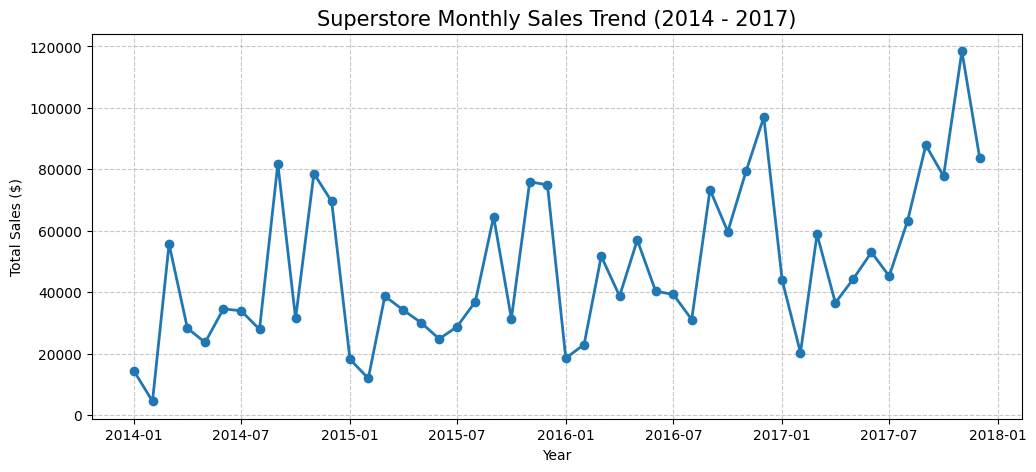

In [37]:
plt.figure(figsize=(12, 5))
plt.plot(monthly_sales, marker='o', color='tab:blue', linewidth=2)
plt.title('Superstore Monthly Sales Trend (2014 - 2017)', fontsize=15)
plt.xlabel('Year')
plt.ylabel('Total Sales ($)')
plt.grid(True, linestyle='--', alpha=0.7)
plt.savefig(' Monthly Sales Trend.png')
plt.show()

## Forecasting Approach

Holt-Winters Exponential Smoothing is used because it captures:
- Long-term sales trends
- Seasonal patterns that repeat yearly

This method is well-suited for retail demand forecasting.


In [32]:
# Split data: Use 2014-2016 for Training, and 2017 for Testing/Validation

train = monthly_sales[:-12]
test = monthly_sales[-12:]

# Fit the model
# trend='add' means sales grow linearly
# seasonal='add' means the holiday peak happens every year

model = ExponentialSmoothing(train, trend='add', seasonal='add', seasonal_periods=12).fit()

# Forecast for the next 12 months (the 'test' period)
forecast = model.forecast(12)

# Evaluation
mae = mean_absolute_error(test, forecast)
print(f"Mean Absolute Error: ${mae:.2f}")

Mean Absolute Error: $11453.74


Validation Plot 

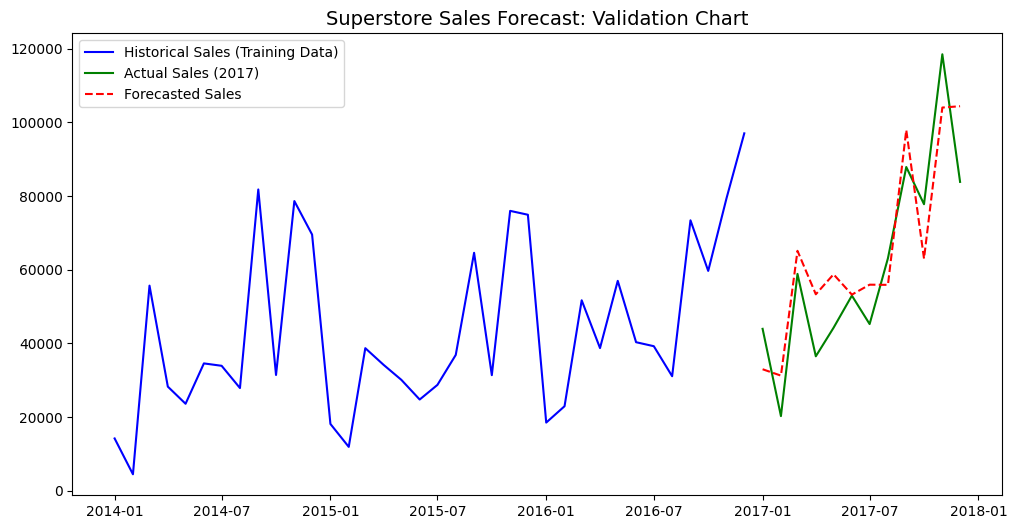

In [35]:
plt.figure(figsize=(12, 6))
plt.plot(train, label='Historical Sales (Training Data)', color='blue')
plt.plot(test, label='Actual Sales (2017)', color='green')
plt.plot(test.index, forecast, label='Forecasted Sales', color='red', linestyle='--')
plt.title('Superstore Sales Forecast: Validation Chart', fontsize=14)
plt.legend()
plt.savefig('sales_validation.png') # This saves the image in your folder
plt.show()

Final Model & Future Forecast

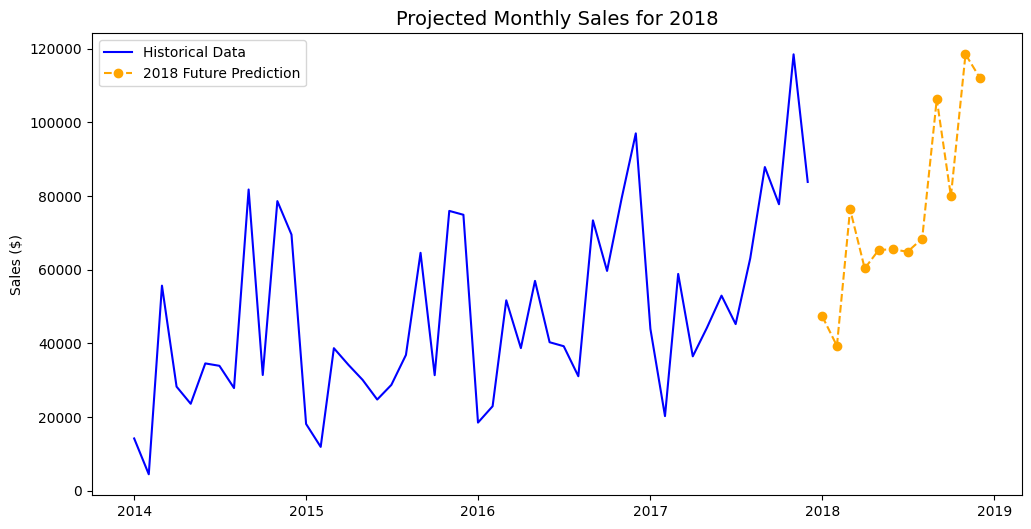

In [36]:
# Train on ALL available data to predict the future
final_model = ExponentialSmoothing(monthly_sales, trend='add', seasonal='add', seasonal_periods=12).fit()
future_2018 = final_model.forecast(12)

plt.figure(figsize=(12, 6))
plt.plot(monthly_sales, label='Historical Data', color='blue')
plt.plot(future_2018, label='2018 Future Prediction', color='orange', marker='o', linestyle='--')
plt.title('Projected Monthly Sales for 2018', fontsize=14)
plt.ylabel('Sales ($)')
plt.legend()
plt.savefig('Projected Monthly Sales for 2018.png') # This saves the image in your folder
plt.show()

Task 1: Business Insights
Seasonality: The data shows a massive spike in sales every November and December. The business should prepare by increasing inventory levels 2 months in advance (September/October).

Growth Trend: There is a steady upward trend year-over-year, indicating the business is expanding.

Actionable Plan: Based on the 2018 forecast, the store owner should expect a "slow period" in February and should use that time for staff training and inventory audits before the mid-year sales pick up.
